# Notebook to make Figure 14 (Appendix C): Observed vs. predicted true and maxL spin magnitude and tilt distributions for GWTC-4.0

In [1]:
import numpy as np 
import json 

import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib import style
style.use('../utils/plotting.mplstyle')
from matplotlib.lines import Line2D

import sys
sys.path.append('../utils')
import plot_utils

## Setup

Load data

In [2]:
# Predicted vs. Observed PPC traces 
eventlevel_predobs = np.load('../data/GWTC4_PPC_traces_event_level.npz', allow_pickle=True)['arr_0'].item()
datalevel_predobs = np.load('../data/GWTC4_PPC_traces_data_level.npz', allow_pickle=True)['arr_0'].item()

Set up plotting aesthetics

In [3]:
# bins for histograms
nbins= 20
chi_bins = np.linspace(0,1,nbins)
costilt_bins = np.linspace(-1,1,nbins)

# histogram kwargs
hist_kws =  dict(histtype='step', lw=1, color='k', density=True)
hist_kws2 =  dict(histtype='stepfilled', alpha=0.6, color=plot_utils.GWTC4_chi_color, density=True)
hist_kws3 =  dict(histtype='stepfilled', alpha=0.6, color=plot_utils.GWTC4_tilt_color, density=True)

## Make figure

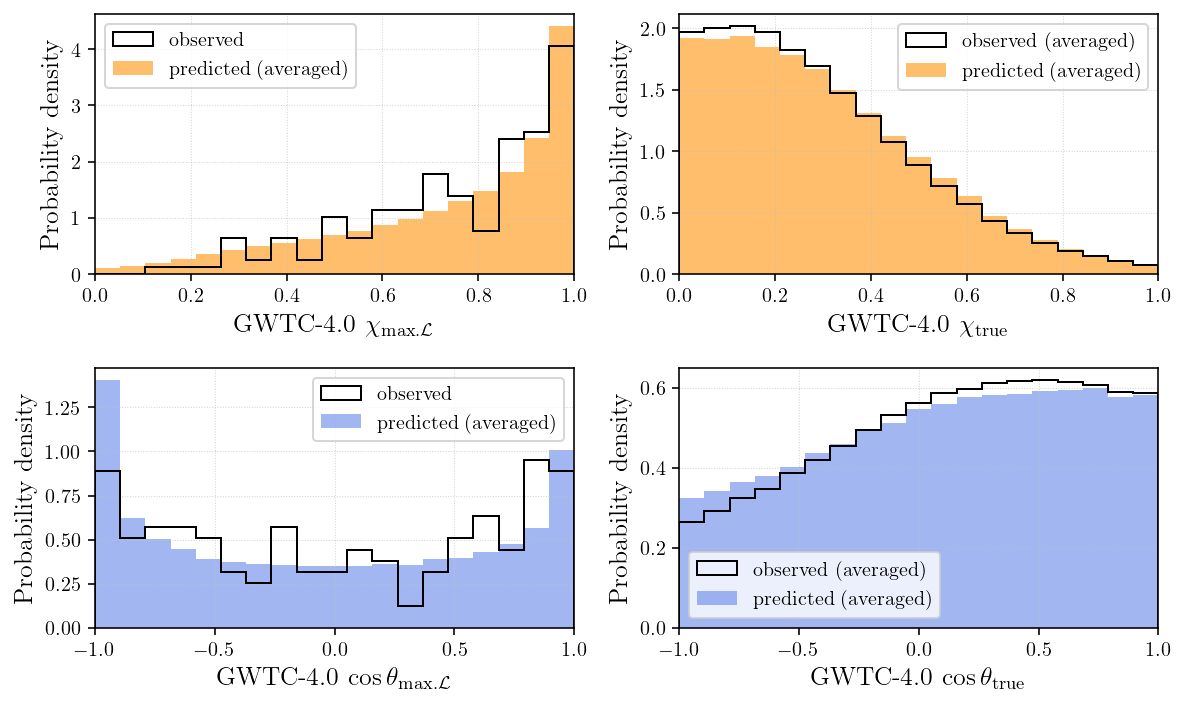

In [4]:
fig, axes = plt.subplots(2,2,figsize=(10/1.2,6/1.2))

axes = axes.flatten()

# Spin magnitude: data level
axes[0].hist(datalevel_predobs['observed']['a'][0], **hist_kws, bins = chi_bins, label=r'observed')
axes[0].hist(datalevel_predobs['predicted']['a'].flatten(), **hist_kws2, bins = chi_bins, label='predicted (averaged)')
axes[0].set_xlabel('GWTC-4.0 '+plot_utils.GWTC4_labels_data_vs_event['a']['data']['label'], fontsize=13)

# Spin magnitude: event level
axes[1].hist(eventlevel_predobs['observed']['a'].flatten(), **hist_kws, bins = chi_bins, label='observed (averaged)')
axes[1].hist(eventlevel_predobs['predicted']['a'].flatten(), **hist_kws2, bins = chi_bins, label='predicted (averaged)')
axes[1].set_xlabel('GWTC-4.0 '+plot_utils.GWTC4_labels_data_vs_event['a']['event']['label'], fontsize=13)

# Spin tilt: data level
axes[2].hist(datalevel_predobs['observed']['cos_tilt'][0], **hist_kws, bins = costilt_bins, label=r'observed')
axes[2].hist(datalevel_predobs['predicted']['cos_tilt'].flatten(), **hist_kws3, bins = costilt_bins, label='predicted (averaged)')
axes[2].set_xlabel('GWTC-4.0 '+plot_utils.GWTC4_labels_data_vs_event['tilt']['data']['label'], fontsize=13)

# Spin tilt: event level
axes[3].hist(eventlevel_predobs['observed']['cos_tilt'].flatten(), **hist_kws, bins = costilt_bins, label='observed (averaged)')
axes[3].hist(eventlevel_predobs['predicted']['cos_tilt'].flatten(), **hist_kws3, bins = costilt_bins, label='predicted (averaged)')
axes[3].set_xlabel('GWTC-4.0 '+plot_utils.GWTC4_labels_data_vs_event['tilt']['event']['label'], fontsize=13)

# Format axes
for ax in axes:
    ax.grid()
    ax.legend()
    ax.set_ylabel('Probability density', fontsize=13)
for ax in axes[:2]:
    ax.set_xlim(0,1)
for ax in axes[2:]:
    ax.set_xlim(-1,1)
    
plt.tight_layout()
plt.subplots_adjust(hspace=0.36)
plt.savefig('figure_14.png', dpi=300, bbox_inches='tight')
plt.show()